In [1]:
from ml_module_rain.models.trained_models import load_trained_model

In [16]:
print('Running imports...')
import os
from captum.attr import IntegratedGradients

os.environ["MKL_THREADING_LAYER"] = "GNU"

import torch # long
from lightning.pytorch import seed_everything
from torch import nn 

import xarray as xr
from tqdm import tqdm
import pandas as pd
import seaborn as sns
import numpy as np
import seaborn.objects as so
import dask.bag as db
import cartopy.crs as ccrs
import argparse
import matplotlib.pyplot as plt
import sys
sys.path.append('/home/rogui7909/code/predict_rain_norway/predict_rain')

from ml_module_rain.models.trained_models import load_trained_model


Running imports...


In [13]:
x = dataloader.train_loader.dataset[0][0][:1]

import torch
import matplotlib.pyplot as plt

activations = {}

def make_hook(name):
    def hook(module, inputs, output):
        # inputs is a tuple
        activations[name] = {
            "input": inputs[0].detach().cpu(),
            "output": output.detach().cpu()
        }
    return hook

hooks = []
for name, module in lightning_model.model.named_modules():
    if len(list(module.children())) == 0:  # leaf modules
        hooks.append(module.register_forward_hook(make_hook(name)))

lightning_model.model.eval()

with torch.no_grad():
    _ = lightning_model.model(x)  # x = your model input

def plot_tensor(t, title="", max_channels=8):
    """
    t: (B, C, H, W) or (B, C)
    """
    t = t[0]  # first batch element

    if t.ndim == 1:
        plt.plot(t)
        plt.title(title)
        plt.show()
        return

    C = min(t.shape[0], max_channels)
    fig, axes = plt.subplots(1, C, figsize=(3*C, 3))
    for i in range(C):
        axes[i].imshow(t[i], aspect="auto")
        axes[i].set_title(f"{title}\nch {i}")
        axes[i].axis("off")
    plt.show()

for name, io in activations.items():
    x_in = io["input"]
    x_out = io["output"]

    print(f"\n{name}")
    print(f"{tuple(x_in.shape)} --> {tuple(x_out.shape)}")
    # print(f"  input : {tuple(x_in.shape)}")
    # print(f"  output: {tuple(x_out.shape)}")

    # if x_in.ndim >= 2:
    #     plot_tensor(x_in, title=f"{name} – input")
    # if x_out.ndim >= 2:
    #     plot_tensor(x_out, title=f"{name} – output")

# 



cnn.convlayer1.convolution
(1, 3, 128, 128) --> (1, 16, 128, 128)

cnn.convlayer1.activation
(1, 16, 128, 128) --> (1, 16, 128, 128)

cnn.convlayer1.maxpool
(1, 16, 128, 128) --> (1, 16, 64, 64)

cnn.convlayer1.dropout
(1, 16, 64, 64) --> (1, 16, 64, 64)

cnn.convlayer1.batchnorm
(1, 16, 64, 64) --> (1, 16, 64, 64)

cnn.convlayer2.convolution
(1, 16, 64, 64) --> (1, 32, 64, 64)

cnn.convlayer2.activation
(1, 32, 64, 64) --> (1, 32, 64, 64)

cnn.convlayer2.maxpool
(1, 32, 64, 64) --> (1, 32, 32, 32)

cnn.convlayer2.dropout
(1, 32, 32, 32) --> (1, 32, 32, 32)

cnn.convlayer2.batchnorm
(1, 32, 32, 32) --> (1, 32, 32, 32)

cnn.convlayer3.convolution
(1, 32, 32, 32) --> (1, 64, 32, 32)

cnn.convlayer3.activation
(1, 64, 32, 32) --> (1, 64, 32, 32)

cnn.convlayer3.maxpool
(1, 64, 32, 32) --> (1, 64, 16, 16)

cnn.convlayer3.dropout
(1, 64, 16, 16) --> (1, 64, 16, 16)

cnn.convlayer3.batchnorm
(1, 64, 16, 16) --> (1, 64, 16, 16)

cnn.convlayer4.convolution
(1, 64, 16, 16) --> (1, 128, 16, 16)

In [18]:
from ml_module_rain.data.preprocessings import add_timesteps, filter_by_season, preprocess_rain, get_loader_from_ds, get_expanded_ds


atm_file_path = '/Data/gfi/users/rogui7909/data/ERA5/dynamical_variables/dl_inputs_day_100km_1940-2024_NPS_v2.zarr'
ds_atm = xr.open_zarr(atm_file_path)
input_variables = ['u850','v850','msl']
ds_mean = ds_atm.data_mean.sel(var_name = input_variables)
ds_std = ds_atm.data_std.sel(var_name = input_variables)
ds_atm = ds_atm[input_variables].to_array('var_name')
ds_atm = (ds_atm-ds_mean)/ds_std
# ds_atm = ds_atm.data_normed.sel(var_name =input_variables )
ds_atm = ds_atm.transpose('time','var_name','x','y')#.isel(x=slice(0,100), y=slice(0,100))
# lon_min, lon_max, lat_min, lat_max = self.config['spatial_extent']
# if ds_atm.latitude.diff('latitude')[0]<0:
#     lat_min, lat_max = lat_max, lat_min
# ds_atm = ds_atm.sel(longitude=slice(lon_min, lon_max), latitude=slice(lat_min, lat_max))
# ds_atm = ds_atm-ds_atm.mean(['longitude','latitude'])

# self.features = ds_atm.astype('float32').load()

file_rain_path = '/Data/gfi/users/rogui7909/data/ERA5/precipitation/pr_era5_daily_westnorway_1940-2024.nc'

ds_rain = xr.open_dataset(file_rain_path).tp.sel(time=ds_atm.time)
ds_rain = add_timesteps(ds_rain, num_timesteps_predicted=7)
ds_rain = filter_by_season(ds_rain,season='all')

ds_rain_threshold = ds_rain.quantile(0.95)
ds_targets = 1*(ds_rain>ds_rain_threshold)

ds_aligned = xr.Dataset(dict(rain=ds_rain, targets=ds_targets, features = ds_atm))

df_targets = ds_aligned.targets.to_series().reset_index()
df_targets['time_of_event'] = df_targets.time + pd.Timedelta(1,'D')*df_targets.timestep
df_targets['timestep_past'] = - df_targets.timestep
time_extr = df_targets.groupby('time_of_event').min().targets.loc[df_targets.groupby('time_of_event').targets.min()==1].index
time_extr = time_extr[time_extr>=pd.to_datetime('1979-01-01')]
time_extr = time_extr[time_extr<pd.to_datetime('2025-01-01')]

all_onetime = []
for t in tqdm(time_extr.values):
    ds_onetime = ds_aligned.sel(time=slice(t-pd.Timedelta('6D'), t))
    if ds_onetime.time.size!=7:
        print(t, 'size issue')
        continue
    ds_onetime['targets'] = ds_onetime.targets[0,6].drop_vars(['time'])
    # ds_onetime['predictions'] = xr.concat([ds_onetime.predictions[k,6-k].drop_vars(['time']).assign_coords(timestep_past=-(6-k)) for k in range(7)], dim='timestep_past',  coords='minimal')
    ds_onetime['rain'] = ds_onetime.rain[0,6].drop_vars(['time'])
    ds_onetime = ds_onetime.assign_coords(time=np.arange(-6,1)).rename(time='timestep_past')
    all_onetime.append(ds_onetime.assign_coords(time_of_event=t))
ds_out = xr.concat(all_onetime, dim='time_of_event', join='exact')

100%|██████████| 840/840 [00:04<00:00, 192.72it/s]


In [25]:
device='cuda'
x_in = torch.tensor(ds_out.features.sel(time_of_event='2016-08-09').transpose('timestep_past','var_name','x','y').values, dtype=torch.float32, device=device).requires_grad_()

In [33]:
dataloader, lightning_model = load_trained_model('loxfbey7')

Data ready:
    Image size: 16384 (128x128)
    Input variables: u850, v850, msl
    10958 samples in train
    2922 samples in validation
    2922 samples in test
    7 Predicted timesteps for future rainfall
    Prediction type: boolean_smooth
    What quantile is considered extreme: 95th of all days


In [41]:
from zennit.composites import EpsilonGammaBox, EpsilonAlpha2Beta1, LayerMapComposite,AlphaBeta, EpsilonAlpha2Beta1Flat, NameLayerMapComposite
from zennit.rules import Epsilon, ZPlus, Norm, Pass, Gamma, Flat
from zennit.types import Convolution, Activation, AvgPool, MaxPool
from zennit.torchvision import VGGCanonizer, SequentialMergeBatchNorm
from torch.nn import BatchNorm2d, Conv2d
import torch.nn as nn
from zennit.composites import NameLayerMapComposite
from zennit.rules import ZPlus, AlphaBeta, Epsilon, Pass
from torch.nn import Linear, Conv2d, BatchNorm2d

name_map = [
    # --- Convs in each DownBlock ---
    (("CNN.convblock0.convolution.convolution",), Flat()),                
    (("CNN.convblock1.convolution.convolution",), ZPlus()),
    (("CNN.convblock2.convolution.convolution",), ZPlus()),
    (("CNN.convblock3.convolution.convolution",), ZPlus()),
    (("CNN.convblock4.convolution.convolution",), ZPlus()),
    # (("CNN.convblock5.convolution.convolution",), ZPlus()),
    # (("MLP.fc1.linearlayer",), Epsilon(epsilon=0)),
]

layer_map = [
    (BatchNorm2d, Pass()),
    (Conv2d, AlphaBeta(2,1)),
    (Linear, Norm()),
    ]
model = lightning_model.model.to(device).eval()
composite = NameLayerMapComposite(name_map=name_map, layer_map=layer_map, canonizers = [SequentialMergeBatchNorm()])
# composite = LayerMapComposite([
#     (BatchNorm2d, Pass()),
#     (Conv2d, AlphaBeta(2,1)),
#     (Linear, Norm()),
#     ], canonizers = [SequentialMergeBatchNorm()])

# composite=  EpsilonAlpha2Beta1()
all_attr = []
all_preds = []
for i in tqdm(range(0,ds_out.time_of_event.size)):
    x_in = torch.tensor(ds_out.features.isel(time_of_event=i).transpose('timestep_past','var_name','x','y').values, dtype=torch.float32, device=device).requires_grad_()
    # x_in = torch.tensor(ds_out.features.sel(time_of_event='2016-08-09').transpose('timestep_past','var_name','x','y').values, dtype=torch.float32, device=device).requires_grad_()
    all_attrs_one_day = []
    all_predictions_one_day = []
    for k in range(7):
        x_input = x_in[k:k+1]
        with composite.context(model) as modified_model:
            # execute the hooked/modified model
            output = modified_model(x_input)
            obj = output[:, 6-k].sum()
            # compute the attribution via the gradient
            attribution, = torch.autograd.grad(obj, x_input, grad_outputs=torch.ones_like(obj))
        all_attrs_one_day.append(attribution)
        all_predictions_one_day.append(obj)
    attr = torch.cat(all_attrs_one_day).detach().cpu()
    preds = torch.stack(all_predictions_one_day).detach().cpu()
    da_attrs = xr.DataArray(
            attr,
            dims=['timestep_past', 'var_name', 'x', 'y'],
            coords=dict(
                timestep_past=ds_out.timestep_past,
                var_name=ds_out.var_name,
                y=ds_out.y,
                x=ds_out.x,
            )
        )    
    da_preds = xr.DataArray(
            preds,
            dims=['timestep_past'],
            coords=dict(
                timestep_past=ds_out.timestep_past,
            )
        )    
    all_attr.append(da_attrs)
    all_preds.append(da_preds)
    break
    # break
# ds_attr_lrp = xr.concat(all_attr, dim='time_of_event').transpose(...,'y','x').assign_coords(time_of_event=ds_out.time_of_event)
# ds_attr_lrp.attrs['lrp_type']= 'zplus'
# ds_out['attributions_lrp'] = ds_attr_lrp
# ds_preds = xr.concat(all_preds, dim='time_of_event').assign_coords(time_of_event=ds_out.time_of_event)
# ds_out['predictions'] = ds_preds
# 

  0%|          | 0/840 [00:00<?, ?it/s]


/tmp/ipykernel_1533260/2437285707.py:2: DeprecationWarning: self.axes is deprecated since 2022.11 in order to align with matplotlibs plt.subplots, use self.axs instead.
  for ax in plot.axes.flat:


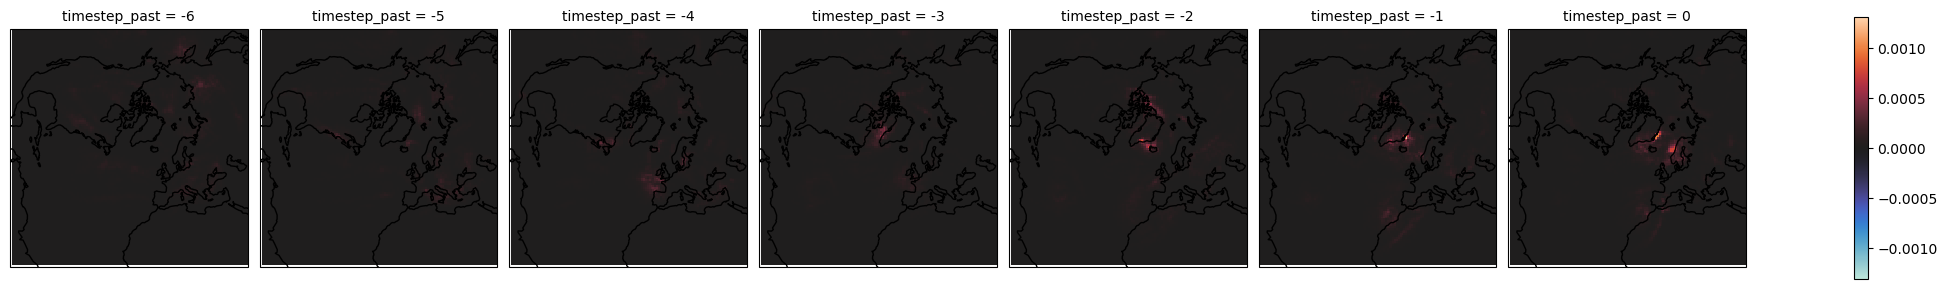

In [42]:
plot = (da_attrs.sum('var_name')).rolling(x=2, y=2,center=True).mean().plot(x='x',y='y',col='timestep_past', cmap='icefire', subplot_kws=dict(projection=ccrs.NorthPolarStereo(0,70),), transform=ccrs.NorthPolarStereo(0,70))
for ax in plot.axes.flat:
    ax.coastlines()
# (da_attrs.sum('var_name')).rolling(x=5, y=5,center=True).mean().plot(col='timestep_past', cmap='icefire',)